In [1]:
library(openxlsx)
library(ggplot2)
library(PRISMA2020)
library(robvis)
library(metafor)

Loading required package: Matrix

Loading required package: metadat


Loading the 'metafor' package (version 3.8-1). For an
introduction to the package please type: help(metafor)




In [6]:
Dataset <- read.xlsx('../../Dataset final (RoB mod).xlsx', 'Combined')
Dataset <- Dataset[c('Study.Identifier', 'Caregiver.intervention.type','Caregiver.intervention.subgroups','Effect.measure','Measurement.method','Measurement.type','Pre_mean','Pre_N','Pre_SD','Post_mean','Post_N','Post_SD','Duration', 'Measurement.points.(days.from.start)')]
# table(Dataset$Effect.measure)

# Caregiver quality of life

In [19]:
meta_df <- Dataset_meta[Dataset_meta$Effect.measure == 'Caregiver quality of life', ]
meta_df.raw <- meta_df[meta_df$Measurement.type	 == 'Raw', ]
meta_df.smd <- meta_df[meta_df$Measurement.type	 == 'SMD', ]
meta_df.smd <- meta_df.smd[meta_df.smd$Caregiver.intervention.type != "No intervention", ]
colnames(meta_df.smd)[which(names(meta_df.smd) == "Post_mean")] <- "yi"
colnames(meta_df.smd)[which(names(meta_df.smd) == "Post_SD")] <- "vi"
# colnames(meta_df.smd)[9:11] <- c("SMD", "MD_N", "MD_SD")
meta_df.raw.ctrl <- meta_df[meta_df$Caregiver.intervention.type == 'No intervention', ]
meta_df.raw.expt <- meta_df[meta_df$Caregiver.intervention.type != 'No intervention', ]
data_cols <- c("Pre_mean","Pre_N","Pre_SD","Post_mean","Post_N","Post_SD")
info_cols <- c("Study.Identifier","Caregiver.intervention.type","Effect.measure","Measurement.method",'Duration',"Measurement.points.(days.from.start)")

meta_df.transformed <- list()
for (i in 1:nrow(meta_df.raw.expt)){
    # print()
    item <- meta_df.raw.expt[i, ]
    
    item_info <- item[info_cols]
    item_data <- item[data_cols]
    colnames(item_data) <- c("Expt_Pre_mean","Expt_Pre_N","Expt_Pre_SD","Expt_Post_mean","Expt_Post_N","Expt_Post_SD")
    
    item_data_ctrl <- meta_df.raw.ctrl[meta_df.raw.ctrl$Study.Identifier == item_info$Study.Identifier, ]
    item_data_ctrl <- item_data_ctrl[item_data_ctrl$Measurement.method	== item_info$Measurement.method, ]
    item_data_ctrl <- item_data_ctrl[item_data_ctrl$"Measurement.points.(days.from.start)"	== item_info$"Measurement.points.(days.from.start)", ]
    item_data_ctrl <- item_data_ctrl[data_cols]
    colnames(item_data_ctrl) <- c("Ctrl_Pre_mean","Ctrl_Pre_N","Ctrl_Pre_SD","Ctrl_Post_mean","Ctrl_Post_N","Ctrl_Post_SD")

    data_item <- cbind(item_info, item_data, item_data_ctrl)
    meta_df.transformed  <- rbind(meta_df.transformed , data_item)
}

meta_df.es <- meta_df.transformed
meta_df.es
# attributes(table(meta_df.es$Study.Identifier))

,Study.Identifier,Caregiver.intervention.type,Effect.measure,Measurement.method,Duration,Measurement.points.(days.from.start),Expt_Pre_mean,Expt_Pre_N,Expt_Pre_SD,Expt_Post_mean,Expt_Post_N,Expt_Post_SD,Ctrl_Pre_mean,Ctrl_Pre_N,Ctrl_Pre_SD,Ctrl_Post_mean,Ctrl_Post_N,Ctrl_Post_SD
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
33,Guerra 2011,Multi-component intervention,Caregiver quality of life,WHO-QoL-Bref,6 months (5 weekly session intervention),180,NA,NA,NA,0.39,27,2.016417,NA,NA,NA,NA,29,NA
45,Lin 2017,Multi-component intervention,Caregiver quality of life,WHO-QoL-Bref,3 months,90,48.82,39,7.83000,55.04,39,5.880000,48.67,39,4.2000,46.77,39,4.00000
57,Mercedeh 2014,Cognitive-behavioural intervention,Caregiver quality of life,SF36,post-intervention (5 weeks),35,58.01,10,24.01000,70.98,10,11.110000,47.61,10,18.3200,37.57,10,12.80000
86,Söylemez 2016,Multi-component intervention,Caregiver quality of life,WHO-QoL-Bref,6 months (3 months post-intervention),180,86.00,35,9.15000,88.51,35,8.280000,87.20,35,5.6900,85.23,35,5.68000
110,Uyar 2019,Multi-component intervention,Caregiver quality of life,SF36,16 weeks,112,83.54,30,13.46701,90.28,26,11.956889,83.77,31,14.3638,77.21,28,14.28863
116,Wang 2012e,Multi-component intervention,Caregiver quality of life,WHO-QoL-Bref,1 month after 24-week intervention,198,97.89,39,14.11000,114.02,39,13.980000,103.71,39,9.2800,88.19,39,7.56000



Random-Effects Model (k = 6; tau^2 estimator: REML)

tau^2 (estimated amount of total heterogeneity): 0.5921 (SE = 0.4976)
tau (square root of estimated tau^2 value):      0.7695
I^2 (total heterogeneity / total variability):   84.03%
H^2 (total variability / sampling variability):  6.26

Test for Heterogeneity:
Q(df = 5) = 30.8617, p-val < .0001

Model Results:

estimate      se    zval    pval   ci.lb   ci.ub      
  1.4577  0.3682  3.9587  <.0001  0.7360  2.1794  *** 

---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


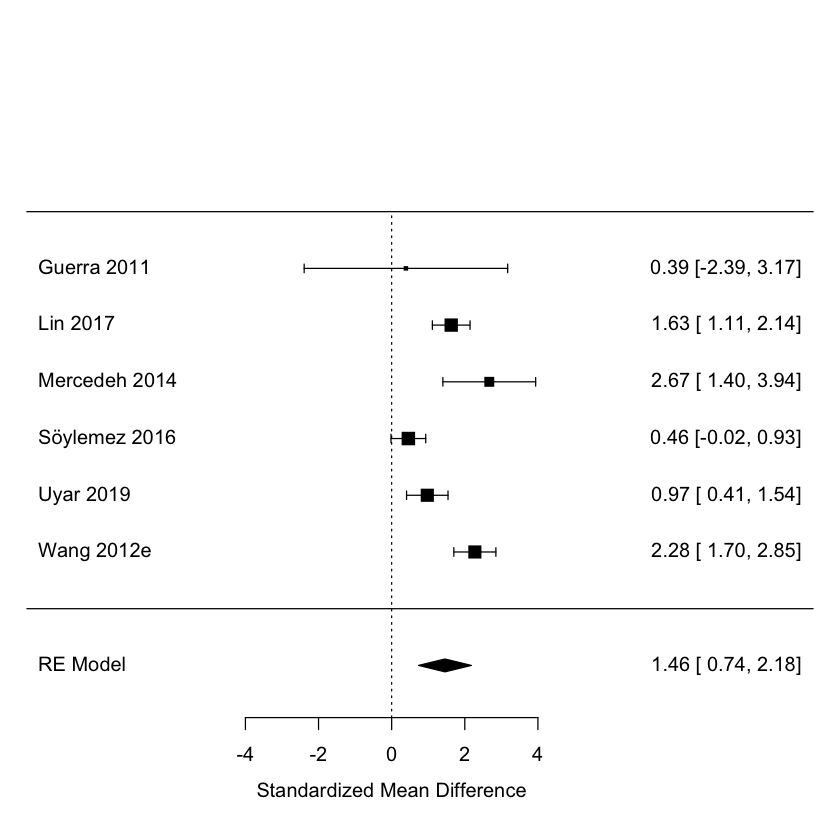


Rank Correlation Test for Funnel Plot Asymmetry

Kendall's tau = 0.3333, p = 0.4694



Estimated number of missing studies on the left side: 0 (SE = 1.6935)

Random-Effects Model (k = 6; tau^2 estimator: REML)

tau^2 (estimated amount of total heterogeneity): 0.5921 (SE = 0.4976)
tau (square root of estimated tau^2 value):      0.7695
I^2 (total heterogeneity / total variability):   84.03%
H^2 (total variability / sampling variability):  6.26

Test for Heterogeneity:
Q(df = 5) = 30.8617, p-val < .0001

Model Results:

estimate      se    zval    pval   ci.lb   ci.ub      
  1.4577  0.3682  3.9587  <.0001  0.7360  2.1794  *** 

---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


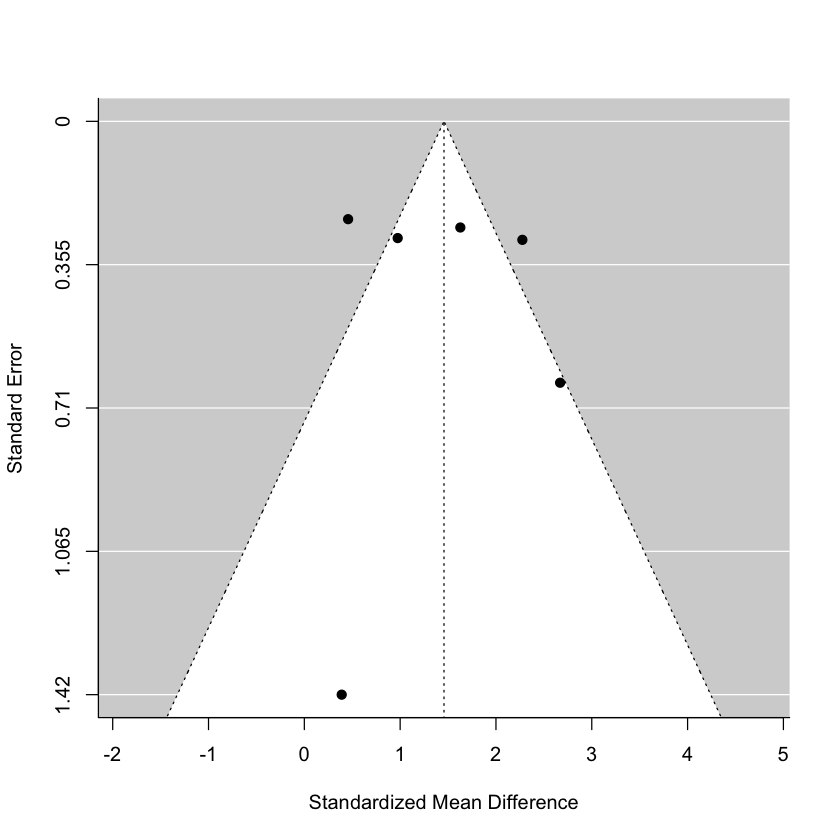

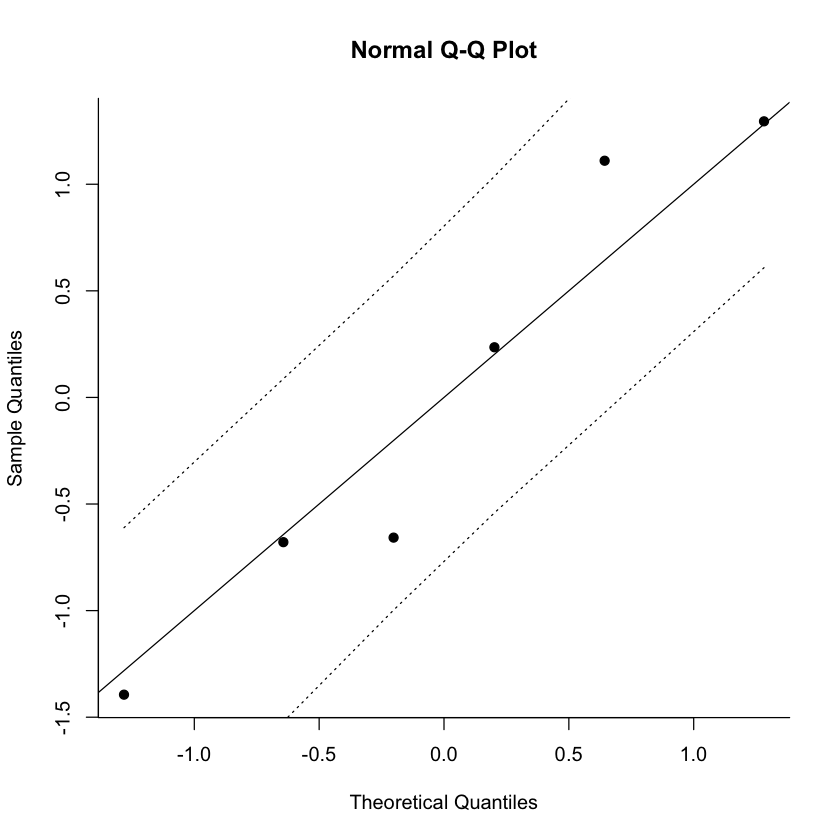

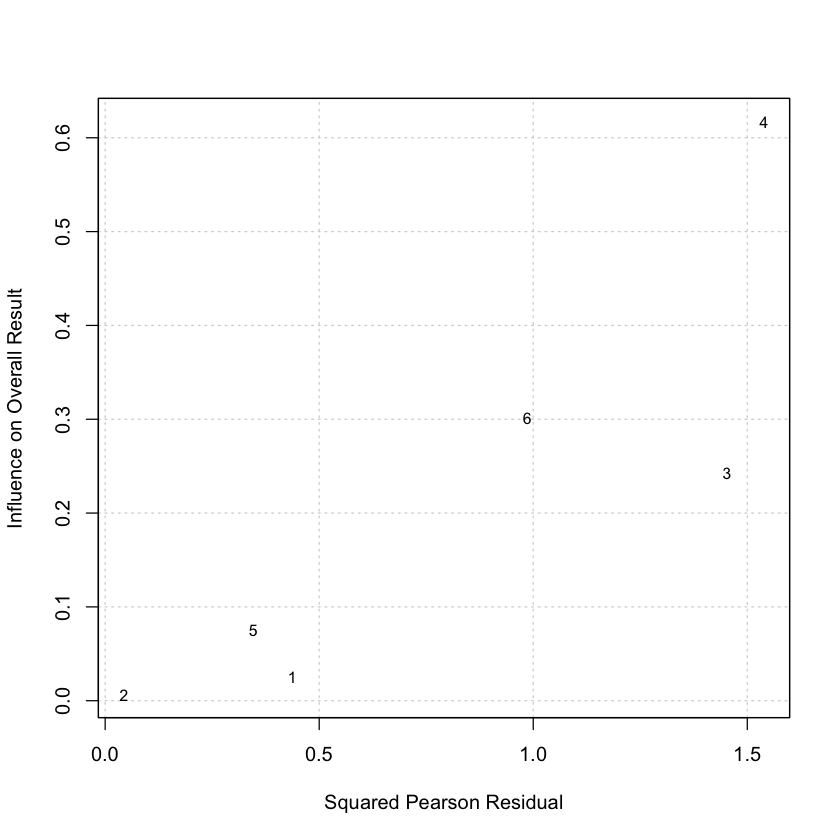

In [12]:
meta_df.es <- escalc(measure="SMD", 
    m1i=Expt_Post_mean, 
    sd1i=Expt_Post_SD, 
    n1i=Expt_Post_N, 
    m2i=Ctrl_Post_mean, 
    sd2i=Ctrl_Post_SD, 
    n2i=Ctrl_Post_N, 
    vtype="UB", 
    data=meta_df.es, 
    slab = Study.Identifier)

for (study in meta_df.smd$Study.Identifier){
    meta_df.es[meta_df.es$Study.Identifier == study, ][c('yi', 'vi')] <- 
        meta_df.smd[meta_df.smd$Study.Identifier == study, ][c('yi', 'vi')]
}
rma(yi, vi, data=meta_df.es)
res <- rma(yi, vi, data=meta_df.es)
forest(res)
funnel(res)
ranktest(res)
trimfill(res)
qqnorm(res)
baujat(res)